                Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0    0.000000e+00       1.532011e-01       8.046978e-01       4.797299e-01   
1    5.000000e-02       1.531619e-01       7.995298e-01       4.797061e-01   
2    1.000000e-01       1.530447e-01       7.842646e-01       4.794988e-01   
3    1.500000e-01       1.528495e-01       7.595959e-01       4.787289e-01   
4    2.000000e-01       1.525769e-01       7.266110e-01       4.768556e-01   
...           ...                ...                ...                ...   
1996 9.980000e+01       3.912896e-09       1.775762e-10       7.441516e-14   
1997 9.985000e+01       3.895402e-09       1.767794e-10       7.407952e-14   
1998 9.990000e+01       3.877972e-09       1.759857e-10       7.373759e-14   
1999 9.995000e+01       3.860599e-09       1.751949e-10       7.338124e-14   
2000 1.000000e+02       3.843285e-09       1.744079e-10       7.301186e-14   

          J_1s(2)      J_2s(2)      J_2p(2)  J_total_carbon  
0

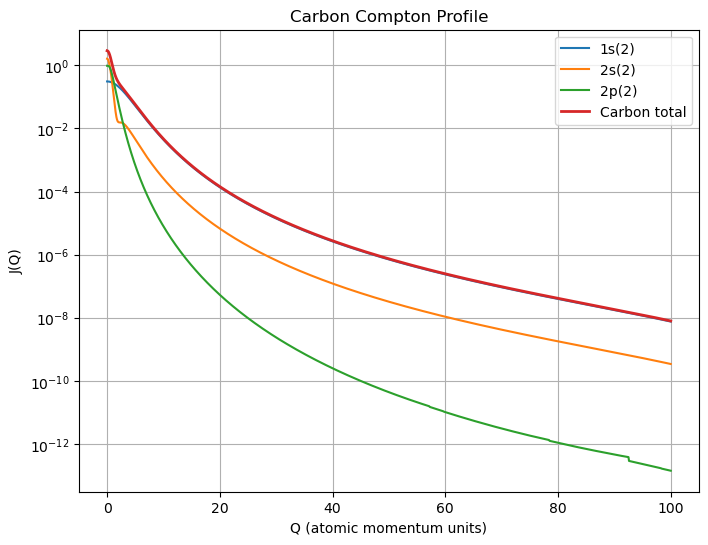

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn
from scipy.integrate import quad, cumulative_trapezoid

# ==================================================
# Carbon R functions after including N
# r in a.u.
# ==================================================

def R_1s(r):
    return (
        17.4697*np.exp(-8.4936*r)
        +10.2078*np.exp(-4.8788*r)
        -7.3550*r**2*np.exp(-15.4660*r)
        +32.1360*r*np.exp(-7.0500*r)
        +0.00789*r*np.exp(-2.2640*r)
        +0.00142*r*np.exp(-1.4747*r)
        -0.000201*r*np.exp(-1.1639*r)
    )

def R_2s(r):
    return (
        -3.5510*np.exp(-8.4936*r)
        +9.4467*np.exp(-4.8788*r)
        -2.3494*r**2*np.exp(-15.4660*r)
        -13.8966*r*np.exp(-7.0500*r)
        -3.5008*r*np.exp(-2.2640*r)
        -1.7660*r*np.exp(-1.4747*r)
        -0.2127*r*np.exp(-1.1639*r)
    )

def R_2p(r):
    return (
        1.0632*r*np.exp(-7.0500*r)
        +1.5316*r*np.exp(-3.2275*r)
        +1.8933*r*np.exp(-2.1908*r)
        +1.1863*r*np.exp(-1.4413*r)
        +0.4299*r*np.exp(-1.0242*r)
    )

# ==================================================
# chi_nl(p)
# ==================================================

def chi_nl(p, R_func, l):
    integrand = lambda r: R_func(r) * spherical_jn(l, p*r) * r**2
    val, err = quad(integrand, 0, np.inf, limit=300)
    return np.sqrt(2/np.pi) * val

# ==================================================
# p and Q grids
# p max should be >= Q max
# ==================================================

dp = 0.05
p = np.arange(0.0, 120.0 + dp, dp)
Q = np.arange(0.0, 100.0 + dp, dp)

# ==================================================
# Calculate chi(p)
# ==================================================

chi_1s = np.array([chi_nl(pp, R_1s, 0) for pp in p])
chi_2s = np.array([chi_nl(pp, R_2s, 0) for pp in p])
chi_2p = np.array([chi_nl(pp, R_2p, 1) for pp in p])

# ==================================================
# Calculate I(p)
# I_nl(p) = |chi_nl(p)|^2 p^2
# ==================================================

I_1s = chi_1s**2 * p**2
I_2s = chi_2s**2 * p**2
I_2p = chi_2p**2 * p**2

# ==================================================
# Calculate J(Q)
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# ==================================================

def J_from_I(p, I, Q):
    integrand = np.zeros_like(p)
    integrand[1:] = I[1:] / p[1:]   # avoid p=0 division

    # reverse cumulative integral from p to infinity
    rev_int = cumulative_trapezoid(integrand[::-1], p[::-1], initial=0)
    J_p = -0.5 * rev_int[::-1]

    # interpolate from p-grid to Q-grid
    J_Q = np.interp(Q, p, J_p)
    return J_Q

J_1s = J_from_I(p, I_1s, Q)
J_2s = J_from_I(p, I_2s, Q)
J_2p = J_from_I(p, I_2p, Q)

# ==================================================
# Carbon total: 1s2 2s2 2p2
# ==================================================

J_1s_2 = 2 * J_1s
J_2s_2 = 2 * J_2s
J_2p_2 = 2 * J_2p

J_total = J_1s_2 + J_2s_2 + J_2p_2

# ==================================================
# Create table
# ==================================================

table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_1s(2)": J_1s_2,
    "J_2s(2)": J_2s_2,
    "J_2p(2)": J_2p_2,
    "J_total_carbon": J_total
})

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.6e}".format)

print(table)

table.to_csv("carbon_JQ_total.csv", index=False)
print("\nSaved as carbon_JQ_total.csv")

# ==================================================
# Plot J(Q)
# ==================================================

plt.figure(figsize=(8,6))
plt.plot(Q, J_1s_2, label="1s(2)")
plt.plot(Q, J_2s_2, label="2s(2)")
plt.plot(Q, J_2p_2, label="2p(2)")
plt.plot(Q, J_total, label="Carbon total", linewidth=2)

plt.xlabel("Q (atomic momentum units)")
plt.ylabel("J(Q)")
plt.title("Carbon Compton Profile")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()